In [1]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import dataloader
import audio_feature_dataloader
import processed_feature_builder
importlib.reload(dataloader)
importlib.reload(audio_feature_dataloader)
importlib.reload(processed_feature_builder)

from dataloader import load_data
from audio_feature_dataloader import build_audio_feature_dataset
from processed_feature_builder import build_processed_two_tower_data, save_processed_two_tower_data

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SENSOR_CSV = DATA_DIR / "wp_node_gps.csv"
GPS_CSV = DATA_DIR / "20260416_150152_gps2_gps.csv"

SAMPLE_MS = 200
RESAMPLE_RATE = f"{SAMPLE_MS}ms"
CHUNK_MS = 10
EXPANDED_PREFIX = "vehicle_sensor_subset_200ms_expanded_features"

context_audio_features = [
    "rms_db", "spectral_centroid_hz", "spectral_flatness",
    "band_20_120_ratio", "band_120_500_ratio", "band_500_2000_ratio",
    "low_to_voice_db", "mid_to_voice_db", "rms_delta_db", "centroid_delta_hz",
    "peak_db", "crest_factor_db", "zcr", "spectral_bandwidth_hz",
    "spectral_rolloff85_hz", "spectral_entropy", "band_20_120_db",
    "band_120_500_db", "band_500_2000_db", "band_2000_6000_db",
    "band_2000_6000_ratio", "flatness_delta",
]

action_audio_features = [
    "rms_db", "spectral_centroid_hz", "spectral_flatness",
    "band_20_120_ratio", "band_120_500_ratio", "low_to_voice_db",
    "band_500_2000_ratio", "mid_to_voice_db", "crest_factor_db", "zcr",
    "spectral_bandwidth_hz", "spectral_rolloff85_hz", "spectral_entropy",
    "band_2000_6000_ratio", "flatness_delta",
]

per_node_required = [
    "rssi_median", "rssi_mad", "rssi_iqr", "rssi_trimmed_mean",
    "rssi_persistence_top3", "rssi_persistence_top5",
    "vehicle_like_score", "construction_like_score", "vehicle_minus_construction_score",
]
global_required = [
    "rssi_top1_top3_gap", "rssi_top1_top5_gap", "global_rssi_mean",
    "global_rssi_std", "global_rssi_range",
] + [
    f"global_{stat}_{feature}"
    for feature in [
        "construction_like_score", "vehicle_like_score", "spectral_entropy",
        "crest_factor_db", "band_2000_6000_ratio",
    ]
    for stat in ["mean", "max", "std", "range"]
]
action_subset_required = [
    "subset_centroid_minus_acoustic_com_x",
    "subset_centroid_minus_acoustic_com_y",
    "subset_centroid_to_acoustic_com_dist",
    "num_signal_top2_in_subset", "num_signal_top3_in_subset", "num_signal_top5_in_subset",
    "best_signal_rank_in_subset", "mean_signal_rank_in_subset", "worst_signal_rank_in_subset",
    "median_rssi", "mad_rssi", "iqr_rssi", "range_rssi",
]
audio_agg_required = [
    f"{stat}_audio_{feature}"
    for feature in action_audio_features
    for stat in ["mean", "max", "min", "std", "range"]
]
score_agg_required = [
    f"{stat}_{feature}"
    for feature in ["construction_like_score", "vehicle_like_score", "vehicle_minus_construction_score"]
    for stat in ["mean", "max", "std"]
]

node_list = sorted(pd.read_csv(SENSOR_CSV)["Node #"].astype(int).tolist())
gdf_cleaned, normalized_cleaned, valid_indices, gdf_nodes = load_data(
    data_dir=DATA_DIR,
    sensor_csv=SENSOR_CSV,
    gps_csv=GPS_CSV,
    node_list=node_list,
    chunk_ms=CHUNK_MS,
    sample_ms=SAMPLE_MS,
    resample_rate=RESAMPLE_RATE,
    plot_gaps=False,
    interpolate_gps=True,
)
audio_feature_df, audio_feature_long, audio_gdf_nodes = build_audio_feature_dataset(
    data_dir=DATA_DIR,
    sensor_csv=SENSOR_CSV,
    node_list=node_list,
    sample_ms=SAMPLE_MS,
    add_cross_sensor=True,
)

expanded_processed = build_processed_two_tower_data(
    gdf_cleaned=gdf_cleaned,
    gdf_nodes=gdf_nodes,
    valid_indices=valid_indices,
    node_list=node_list,
    audio_feature_long=audio_feature_long,
    history_steps=5,
    max_subset_size=3,
    utility_second_weight=0.45,
    utility_third_weight=0.20,
    softmax_temperature=4.0,
    context_audio_features=context_audio_features,
    action_audio_features=action_audio_features,
    include_audio_derived_features=True,
    verbose=True,
    progress_every=1500,
)
expanded_paths = save_processed_two_tower_data(
    expanded_processed,
    processed_dir=PROCESSED_DIR,
    prefix=EXPANDED_PREFIX,
)

meta = expanded_processed["meta"]
missing_context_audio = sorted(set(context_audio_features) - set(meta["context_audio_features"]))
missing_action_audio = sorted(set(action_audio_features) - set(meta["action_audio_features"]))
assert not missing_context_audio, missing_context_audio
assert not missing_action_audio, missing_action_audio

context_names = set(meta["context_feature_names"])
node_feature_cols = set(expanded_processed["node_feature_df"].columns)
feature_wide_cols = set(expanded_processed["feature_wide_df"].columns)
for node in meta["ordered_nodes"]:
    for feature in per_node_required:
        assert feature in node_feature_cols, f"missing node_feature_df column: {feature}"
        assert f"n{node}_{feature}" in context_names, f"missing context feature: n{node}_{feature}"
        assert f"n{node}_{feature}" in feature_wide_cols, f"missing feature_wide column: n{node}_{feature}"
    for feature in context_audio_features:
        assert f"n{node}_audio_{feature}" in context_names, f"missing context audio: n{node}_audio_{feature}"

global_names = set(meta["global_feature_names"])
for feature in global_required:
    assert feature in global_names, f"missing global context feature: {feature}"
    assert feature in feature_wide_cols, f"missing feature_wide global column: {feature}"

action_names = set(meta["action_feature_names"])
for feature in action_subset_required + audio_agg_required + score_agg_required:
    assert feature in action_names, f"missing action feature: {feature}"

arrays = np.load(expanded_paths["arrays_npz"])
assert arrays["C_by_time"].shape[1] == meta["context_dim"] == len(meta["context_feature_names"])
assert arrays["A_examples"].shape[1] == meta["action_raw_dim"] == len(meta["action_feature_names"])

leak_tokens = ("distance_to", "vehicle_x", "vehicle_y", "latitude", "longitude")
feature_names = list(meta["context_feature_names"]) + list(meta["action_feature_names"])
leaky_features = [name for name in feature_names if any(tok in name.lower() for tok in leak_tokens)]
assert not leaky_features, leaky_features[:20]

print("expanded processed prefix:", EXPANDED_PREFIX)
print("context_dim:", meta["context_dim"])
print("action_dim:", meta["action_raw_dim"])
print("times/examples:", meta["num_times"], meta["num_examples"])
print("all requested expanded features are present; no feature-side vehicle coordinate leakage detected")
display(pd.DataFrame([{"artifact": k, "path": str(v)} for k, v in expanded_paths.items()]))


Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_11_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_12_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_13_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_14_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_15_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\data\raw\20260416_150152_dvpg_gq_orin_16_respeaker.flac
Node 11: 155480 rows loaded, time range: 2026-04-16 15:01:52 to 2026-04-16 15:27:46.790000
Node 12: 155490 rows loaded, time range: 2026-04-16 15:01:52 to 2026-04-16 15:27:46.890000
Node 13: 15549

,artifact,path
0,feature_wide_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
1,node_features_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
2,ground_truth_nodes_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
3,ground_truth_vehicle_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
4,sensor_geometry_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
5,sequence_pkl,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
6,examples_pkl,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
7,examples_index_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
8,arrays_npz,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
9,meta_json,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...


In [2]:
import importlib
import two_tower_training
importlib.reload(two_tower_training)

from two_tower_training import TrainConfig, compare_on_common_objectives, run_config_grid, summarize_results

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVED_OBJECTIVES = [
    {"name": "saved_rational", "utility_name": "saved", "utility_kwargs": {}},
    {"name": "contains_closest", "utility_name": "closest_binary", "utility_kwargs": {}},
]

expanded_h512_config = TrainConfig(
    run_name="expanded_saved_h512_d2_e8",
    utility_name="saved",
    hidden=512,
    emb_dim=8,
    depth=2,
    dropout=0.05,
    combine_mode="mul_only",
    loss_name="mse",
    max_epochs=50,
    patience=16,
    batch_size=8192,
    lr=1e-3,
    weight_decay=1e-4,
    seed=22,
    log_every=1,
)

expanded_results = run_config_grid(
    PROCESSED_DIR,
    [expanded_h512_config],
    prefix=EXPANDED_PREFIX,
    device=DEVICE,
)
expanded_summary_df = summarize_results(expanded_results)
expanded_common_eval_df = compare_on_common_objectives(expanded_results, SAVED_OBJECTIVES)
display(expanded_summary_df)
display(expanded_common_eval_df[expanded_common_eval_df["split"].eq("test")].reset_index(drop=True))


expanded_saved_h512_d2_e8 ep 001/050* loss=0.04510 val_rmse=0.1434 top1=0.238 top3=0.449 reg=0.0357 rank=5.98 11s
expanded_saved_h512_d2_e8 ep 002/050  loss=0.01762 val_rmse=0.1354 top1=0.147 top3=0.391 reg=0.0406 rank=6.46 22s
expanded_saved_h512_d2_e8 ep 003/050  loss=0.01254 val_rmse=0.1297 top1=0.162 top3=0.385 reg=0.0362 rank=6.03 33s
expanded_saved_h512_d2_e8 ep 004/050* loss=0.00994 val_rmse=0.1244 top1=0.161 top3=0.419 reg=0.0315 rank=5.53 44s
expanded_saved_h512_d2_e8 ep 005/050* loss=0.00827 val_rmse=0.1247 top1=0.185 top3=0.453 reg=0.0289 rank=5.23 55s
expanded_saved_h512_d2_e8 ep 006/050* loss=0.00705 val_rmse=0.1262 top1=0.203 top3=0.466 reg=0.0287 rank=5.20 66s
expanded_saved_h512_d2_e8 ep 007/050* loss=0.00613 val_rmse=0.1244 top1=0.213 top3=0.487 reg=0.0281 rank=5.14 77s
expanded_saved_h512_d2_e8 ep 008/050* loss=0.00544 val_rmse=0.1261 top1=0.243 top3=0.500 reg=0.0274 rank=5.05 90s
expanded_saved_h512_d2_e8 ep 009/050* loss=0.00490 val_rmse=0.1221 top1=0.238 top3=0.508

,run_name,utility,hidden,emb_dim,depth,dropout,combine,loss,best_epoch,train_rmse,...,val_avg_regret,val_avg_norm_regret,test_rmse,test_mae,test_r2,test_top1,test_top3,test_mean_rank,test_avg_regret,test_avg_norm_regret
0,expanded_saved_h512_d2_e8,saved,512,8,2,0.05,mul_only,mse,41,0.019546,...,0.022904,0.050454,0.116675,0.083843,0.656293,0.283322,0.544541,4.425318,0.023707,0.047672


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,expanded_saved_h512_d2_e8,saved,contains_closest,test,512,8,mul_only,0.943068,0.943068,1.910918,0.056932,0.056932
1,expanded_saved_h512_d2_e8,saved,saved_rational,test,512,8,mul_only,0.283322,0.544541,4.425318,0.023707,0.047672


In [4]:
# Same model and saved utility, but no waveform/frequency features beyond RSSI-derived features.
# Sensor GPS geometry and RSSI history/rank/persistence features remain available.

RSSI_GEOMETRY_PREFIX = "vehicle_sensor_subset_200ms_rssi_geometry_only"

rssi_geometry_processed = build_processed_two_tower_data(
    gdf_cleaned=gdf_cleaned,
    gdf_nodes=gdf_nodes,
    valid_indices=valid_indices,
    node_list=node_list,
    audio_feature_long=None,
    history_steps=5,
    max_subset_size=3,
    utility_second_weight=0.45,
    utility_third_weight=0.20,
    softmax_temperature=4.0,
    context_audio_features=[],
    action_audio_features=[],
    include_audio_derived_features=False,
    verbose=True,
    progress_every=1500,
)
rssi_geometry_paths = save_processed_two_tower_data(
    rssi_geometry_processed,
    processed_dir=PROCESSED_DIR,
    prefix=RSSI_GEOMETRY_PREFIX,
)

rssi_meta = rssi_geometry_processed["meta"]
assert rssi_meta["context_audio_features"] == []
assert rssi_meta["action_audio_features"] == []
assert rssi_meta["derived_audio_score_features"] == []
assert not [name for name in rssi_meta["context_feature_names"] if "audio_" in name]
assert not [name for name in rssi_meta["action_feature_names"] if "audio_" in name]

rssi_geometry_h512_config = TrainConfig(
    run_name="rssi_geometry_saved_h512_d2_e8",
    utility_name="saved",
    hidden=512,
    emb_dim=8,
    depth=2,
    dropout=0.05,
    combine_mode="mul_only",
    loss_name="mse",
    max_epochs=50,
    patience=16,
    batch_size=8192,
    lr=1e-3,
    weight_decay=1e-4,
    seed=22,
    log_every=1,
)

rssi_geometry_results = run_config_grid(
    PROCESSED_DIR,
    [rssi_geometry_h512_config],
    prefix=RSSI_GEOMETRY_PREFIX,
    device=DEVICE,
)
rssi_geometry_summary_df = summarize_results(rssi_geometry_results)
rssi_geometry_common_eval_df = compare_on_common_objectives(rssi_geometry_results, SAVED_OBJECTIVES)

display(rssi_geometry_summary_df)
display(rssi_geometry_common_eval_df[rssi_geometry_common_eval_df["split"].eq("test")].reset_index(drop=True))

if "expanded_results" in globals():
    ablation_eval_df = compare_on_common_objectives(
        expanded_results + rssi_geometry_results,
        SAVED_OBJECTIVES,
    )
    display(
        ablation_eval_df[ablation_eval_df["split"].eq("test")]
        .sort_values(["eval_objective", "avg_norm_regret", "mean_rank"])
        .reset_index(drop=True)
    )


valid timesteps: 7465
ordered nodes: [11, 12, 13, 14, 15, 16]
temporal features: 1/7465
temporal features: 1500/7465
temporal features: 3000/7465
temporal features: 4500/7465
temporal features: 6000/7465
temporal features: 7465/7465
node rows: 1/7465
node rows: 1500/7465
node rows: 3000/7465
node rows: 4500/7465
node rows: 6000/7465
node rows: 7465/7465
action rows: 1/7465
action rows: 1500/7465
action rows: 3000/7465
action rows: 4500/7465
action rows: 6000/7465
action rows: 7465/7465
processed two-tower data ready
sequence_df: (7465, 5)
examples_df: (306065, 15)
context_dim: 99
action_raw_dim: 76
rssi_geometry_saved_h512_d2_e8 ep 001/050* loss=0.04696 val_rmse=0.1697 top1=0.204 top3=0.352 reg=0.0712 rank=8.17 11s
rssi_geometry_saved_h512_d2_e8 ep 002/050* loss=0.02651 val_rmse=0.1692 top1=0.173 top3=0.293 reg=0.0678 rank=8.62 22s
rssi_geometry_saved_h512_d2_e8 ep 003/050  loss=0.02266 val_rmse=0.1787 top1=0.175 top3=0.281 reg=0.0820 rank=9.99 33s
rssi_geometry_saved_h512_d2_e8 ep 004

,run_name,utility,hidden,emb_dim,depth,dropout,combine,loss,best_epoch,train_rmse,...,val_avg_regret,val_avg_norm_regret,test_rmse,test_mae,test_r2,test_top1,test_top3,test_mean_rank,test_avg_regret,test_avg_norm_regret
0,rssi_geometry_saved_h512_d2_e8,saved,512,8,2,0.05,mul_only,mse,2,0.149376,...,0.067825,0.135486,0.160671,0.123608,0.348208,0.22639,0.330208,8.073677,0.072984,0.134118


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,rssi_geometry_saved_h512_d2_e8,saved,contains_closest,test,512,8,mul_only,0.77361,0.773610,4.622237,0.226390,0.226390
1,rssi_geometry_saved_h512_d2_e8,saved,saved_rational,test,512,8,mul_only,0.22639,0.330208,8.073677,0.072984,0.134118


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,expanded_saved_h512_d2_e8,saved,contains_closest,test,512,8,mul_only,0.943068,0.943068,1.910918,0.056932,0.056932
1,rssi_geometry_saved_h512_d2_e8,saved,contains_closest,test,512,8,mul_only,0.773610,0.773610,4.622237,0.226390,0.226390
2,expanded_saved_h512_d2_e8,saved,saved_rational,test,512,8,mul_only,0.283322,0.544541,4.425318,0.023707,0.047672
3,rssi_geometry_saved_h512_d2_e8,saved,saved_rational,test,512,8,mul_only,0.226390,0.330208,8.073677,0.072984,0.134118


In [5]:
import importlib
import pandas as pd
from dataclasses import replace

import two_tower_training
importlib.reload(two_tower_training)

from two_tower_training import (
    TrainConfig,
    compare_on_common_objectives,
    run_config_grid,
    summarize_results,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SAVED_OBJECTIVES = [
    {"name": "saved_rational", "utility_name": "saved", "utility_kwargs": {}},
    {"name": "contains_closest", "utility_name": "closest_binary", "utility_kwargs": {}},
]

# Your current expanded baseline.
base_config = TrainConfig(
    run_name="expanded_saved_h512_d2_e8",
    utility_name="saved",
    hidden=512,
    emb_dim=8,
    depth=2,
    dropout=0.05,
    combine_mode="mul_only",
    loss_name="mse",
    max_epochs=50,
    patience=16,
    batch_size=8192,
    lr=1e-3,
    weight_decay=1e-4,
    seed=22,
    log_every=1,
)

# One-change-at-a-time configs around the baseline.
one_change_configs = [
    # 1. Main bottleneck test: 8 -> 16 embedding.
    replace(
        base_config,
        run_name="expanded_saved_h512_d2_e16",
        emb_dim=16,
    ),

    # 2. Stronger bottleneck test: 8 -> 24 embedding.
    # Still not insane for the later linearized bandit: d = 1 + 3*24 = 73.
    replace(
        base_config,
        run_name="expanded_saved_h512_d2_e24",
        emb_dim=24,
    ),

    # 3. Dropout regularization test.
    replace(
        base_config,
        run_name="expanded_saved_h512_d2_e8_drop010",
        dropout=0.10,
    ),

    # 4. Weight-decay regularization test.
    replace(
        base_config,
        run_name="expanded_saved_h512_d2_e8_wd5e4",
        weight_decay=5e-4,
    ),

    # 5. Noisy-label robustness test.
    replace(
        base_config,
        run_name="expanded_saved_h512_d2_e8_smoothl1",
        loss_name="smooth_l1",
    ),
]

one_change_results = run_config_grid(
    PROCESSED_DIR,
    one_change_configs,
    prefix=EXPANDED_PREFIX,
    device=DEVICE,
)

one_change_summary_df = summarize_results(one_change_results)

one_change_common_eval_df = compare_on_common_objectives(
    one_change_results,
    SAVED_OBJECTIVES,
)

display(one_change_summary_df)

display(
    one_change_common_eval_df[
        one_change_common_eval_df["split"].eq("test")
    ].reset_index(drop=True)
)

expanded_saved_h512_d2_e16 ep 001/050* loss=0.04178 val_rmse=0.1456 top1=0.217 top3=0.395 reg=0.0408 rank=6.45 12s
expanded_saved_h512_d2_e16 ep 002/050* loss=0.01627 val_rmse=0.1311 top1=0.172 top3=0.376 reg=0.0354 rank=6.07 23s
expanded_saved_h512_d2_e16 ep 003/050* loss=0.01144 val_rmse=0.1313 top1=0.168 top3=0.376 reg=0.0352 rank=6.04 35s
expanded_saved_h512_d2_e16 ep 004/050* loss=0.00891 val_rmse=0.1335 top1=0.200 top3=0.405 reg=0.0339 rank=5.81 47s
expanded_saved_h512_d2_e16 ep 005/050* loss=0.00730 val_rmse=0.1322 top1=0.202 top3=0.420 reg=0.0325 rank=5.67 59s
expanded_saved_h512_d2_e16 ep 006/050* loss=0.00617 val_rmse=0.1306 top1=0.223 top3=0.440 reg=0.0298 rank=5.37 71s
expanded_saved_h512_d2_e16 ep 007/050* loss=0.00532 val_rmse=0.1275 top1=0.228 top3=0.433 reg=0.0296 rank=5.34 83s
expanded_saved_h512_d2_e16 ep 008/050* loss=0.00470 val_rmse=0.1253 top1=0.228 top3=0.453 reg=0.0273 rank=5.09 95s
expanded_saved_h512_d2_e16 ep 009/050* loss=0.00422 val_rmse=0.1266 top1=0.262 t

,run_name,utility,hidden,emb_dim,depth,dropout,combine,loss,best_epoch,train_rmse,...,val_avg_regret,val_avg_norm_regret,test_rmse,test_mae,test_r2,test_top1,test_top3,test_mean_rank,test_avg_regret,test_avg_norm_regret
0,expanded_saved_h512_d2_e16,saved,512,16,2,0.05,mul_only,mse,49,0.015718,...,0.021587,0.047695,0.117341,0.084514,0.652360,0.358339,0.606162,4.034159,0.021643,0.042809
1,expanded_saved_h512_d2_e8_smoothl1,saved,512,8,2,0.05,mul_only,smooth_l1,8,0.045941,...,0.022192,0.048724,0.119032,0.088301,0.642266,0.215673,0.482920,4.508372,0.023325,0.046852
2,expanded_saved_h512_d2_e8_drop010,saved,512,8,2,0.10,mul_only,mse,30,0.029872,...,0.022825,0.050606,0.118083,0.085402,0.647949,0.279303,0.535164,4.306095,0.023078,0.045778
3,expanded_saved_h512_d2_e8_wd5e4,saved,512,8,2,0.05,mul_only,mse,41,0.019413,...,0.022854,0.050628,0.115975,0.083389,0.660402,0.282652,0.549230,4.342264,0.023081,0.046444
4,expanded_saved_h512_d2_e24,saved,512,24,2,0.05,mul_only,mse,28,0.024481,...,0.023883,0.049692,0.123081,0.090066,0.617515,0.249163,0.459478,4.718687,0.025646,0.050379


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,expanded_saved_h512_d2_e8_smoothl1,saved,contains_closest,test,512,8,mul_only,0.957803,0.957803,1.675151,0.042197,0.042197
1,expanded_saved_h512_d2_e8_drop010,saved,contains_closest,test,512,8,mul_only,0.950435,0.950435,1.793034,0.049565,0.049565
2,expanded_saved_h512_d2_e8_wd5e4,saved,contains_closest,test,512,8,mul_only,0.945747,0.945747,1.868051,0.054253,0.054253
3,expanded_saved_h512_d2_e16,saved,contains_closest,test,512,16,mul_only,0.945077,0.945077,1.878768,0.054923,0.054923
4,expanded_saved_h512_d2_e24,saved,contains_closest,test,512,24,mul_only,0.942398,0.942398,1.921634,0.057602,0.057602
5,expanded_saved_h512_d2_e16,saved,saved_rational,test,512,16,mul_only,0.358339,0.606162,4.034159,0.021643,0.042809
6,expanded_saved_h512_d2_e8_drop010,saved,saved_rational,test,512,8,mul_only,0.279303,0.535164,4.306095,0.023078,0.045778
7,expanded_saved_h512_d2_e8_wd5e4,saved,saved_rational,test,512,8,mul_only,0.282652,0.549230,4.342264,0.023081,0.046444
8,expanded_saved_h512_d2_e8_smoothl1,saved,saved_rational,test,512,8,mul_only,0.215673,0.482920,4.508372,0.023325,0.046852
9,expanded_saved_h512_d2_e24,saved,saved_rational,test,512,24,mul_only,0.249163,0.459478,4.718687,0.025646,0.050379


In [7]:
import importlib
import pandas as pd
from dataclasses import replace

import two_tower_training
importlib.reload(two_tower_training)

from two_tower_training import (
    TrainConfig,
    compare_on_common_objectives,
    run_config_grid,
    summarize_results,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SAVED_OBJECTIVES = [
    {"name": "saved_rational", "utility_name": "saved", "utility_kwargs": {}},
    {"name": "contains_closest", "utility_name": "closest_binary", "utility_kwargs": {}},
]

# New baseline: best from the previous batch.
base_e16_config = TrainConfig(
    run_name="expanded_saved_h512_d2_e16",
    utility_name="saved",
    hidden=512,
    emb_dim=16,
    depth=2,
    dropout=0.05,
    combine_mode="mul_only",
    loss_name="mse",
    max_epochs=50,
    patience=16,
    batch_size=8192,
    lr=1e-3,
    weight_decay=1e-4,
    seed=22,
    log_every=1,
)

e16_probe_configs = [
    # 1. Smaller embedding near the winner.
    replace(
        base_e16_config,
        run_name="expanded_saved_h512_d2_e12",
        emb_dim=12,
    ),

    # 2. Larger embedding near the winner, but below the bad e24 case.
    replace(
        base_e16_config,
        run_name="expanded_saved_h512_d2_e20",
        emb_dim=20,
    ),

    # 3. More dropout around e16.
    replace(
        base_e16_config,
        run_name="expanded_saved_h512_d2_e16_drop010",
        dropout=0.10,
    ),

    # 4. More weight decay around e16.
    replace(
        base_e16_config,
        run_name="expanded_saved_h512_d2_e16_wd5e4",
        weight_decay=5e-4,
    ),

    # 5. Lower learning rate around e16.
    replace(
        base_e16_config,
        run_name="expanded_saved_h512_d2_e16_lr5e4",
        lr=5e-4,
    ),
]

e16_probe_results = run_config_grid(
    PROCESSED_DIR,
    e16_probe_configs,
    prefix=EXPANDED_PREFIX,
    device=DEVICE,
)

e16_probe_summary_df = summarize_results(e16_probe_results)

e16_probe_common_eval_df = compare_on_common_objectives(
    e16_probe_results,
    SAVED_OBJECTIVES,
)

display(e16_probe_summary_df)

display(
    e16_probe_common_eval_df[
        e16_probe_common_eval_df["split"].eq("test")
    ].reset_index(drop=True)
)

expanded_saved_h512_d2_e12 ep 001/050* loss=0.05611 val_rmse=0.1463 top1=0.152 top3=0.393 reg=0.0432 rank=6.77 13s
expanded_saved_h512_d2_e12 ep 002/050* loss=0.01861 val_rmse=0.1312 top1=0.126 top3=0.354 reg=0.0378 rank=6.30 23s
expanded_saved_h512_d2_e12 ep 003/050* loss=0.01319 val_rmse=0.1313 top1=0.123 top3=0.386 reg=0.0348 rank=6.06 34s
expanded_saved_h512_d2_e12 ep 004/050* loss=0.01049 val_rmse=0.1302 top1=0.167 top3=0.420 reg=0.0306 rank=5.56 44s
expanded_saved_h512_d2_e12 ep 005/050* loss=0.00875 val_rmse=0.1312 top1=0.210 top3=0.475 reg=0.0278 rank=5.17 55s
expanded_saved_h512_d2_e12 ep 006/050* loss=0.00746 val_rmse=0.1302 top1=0.217 top3=0.497 reg=0.0260 rank=4.93 65s
expanded_saved_h512_d2_e12 ep 007/050* loss=0.00656 val_rmse=0.1310 top1=0.220 top3=0.491 reg=0.0255 rank=4.89 75s
expanded_saved_h512_d2_e12 ep 008/050  loss=0.00583 val_rmse=0.1304 top1=0.222 top3=0.490 reg=0.0258 rank=4.94 85s
expanded_saved_h512_d2_e12 ep 009/050* loss=0.00520 val_rmse=0.1314 top1=0.236 t

,run_name,utility,hidden,emb_dim,depth,dropout,combine,loss,best_epoch,train_rmse,...,val_avg_regret,val_avg_norm_regret,test_rmse,test_mae,test_r2,test_top1,test_top3,test_mean_rank,test_avg_regret,test_avg_norm_regret
0,expanded_saved_h512_d2_e16_wd5e4,saved,512,16,2,0.05,mul_only,mse,36,0.018505,...,0.021825,0.048203,0.118466,0.086326,0.645658,0.316812,0.589417,4.198928,0.022763,0.045469
1,expanded_saved_h512_d2_e16_drop010,saved,512,16,2,0.10,mul_only,mse,30,0.023312,...,0.022876,0.049997,0.115619,0.083909,0.662486,0.358339,0.584059,4.152043,0.022200,0.044528
2,expanded_saved_h512_d2_e16_lr5e4,saved,512,16,2,0.05,mul_only,mse,34,0.026671,...,0.023013,0.048286,0.116906,0.086559,0.654928,0.290690,0.531815,4.434025,0.023385,0.046734
3,expanded_saved_h512_d2_e12,saved,512,12,2,0.05,mul_only,mse,13,0.045883,...,0.023032,0.048745,0.119445,0.089894,0.639781,0.221701,0.486269,4.837910,0.026475,0.052236
4,expanded_saved_h512_d2_e20,saved,512,20,2,0.05,mul_only,mse,50,0.014085,...,0.024476,0.051506,0.117138,0.085308,0.653557,0.313463,0.604823,4.383121,0.024184,0.048838


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,expanded_saved_h512_d2_e16_lr5e4,saved,contains_closest,test,512,16,mul_only,0.947756,0.947756,1.835901,0.052244,0.052244
1,expanded_saved_h512_d2_e16_drop010,saved,contains_closest,test,512,16,mul_only,0.945077,0.945077,1.878768,0.054923,0.054923
2,expanded_saved_h512_d2_e12,saved,contains_closest,test,512,12,mul_only,0.943737,0.943737,1.900201,0.056263,0.056263
3,expanded_saved_h512_d2_e16_wd5e4,saved,contains_closest,test,512,16,mul_only,0.941058,0.941058,1.943068,0.058942,0.058942
4,expanded_saved_h512_d2_e20,saved,contains_closest,test,512,20,mul_only,0.933691,0.933691,2.060951,0.066309,0.066309
5,expanded_saved_h512_d2_e16_drop010,saved,saved_rational,test,512,16,mul_only,0.358339,0.584059,4.152043,0.022200,0.044528
6,expanded_saved_h512_d2_e16_wd5e4,saved,saved_rational,test,512,16,mul_only,0.316812,0.589417,4.198928,0.022763,0.045469
7,expanded_saved_h512_d2_e16_lr5e4,saved,saved_rational,test,512,16,mul_only,0.290690,0.531815,4.434025,0.023385,0.046734
8,expanded_saved_h512_d2_e20,saved,saved_rational,test,512,20,mul_only,0.313463,0.604823,4.383121,0.024184,0.048838
9,expanded_saved_h512_d2_e12,saved,saved_rational,test,512,12,mul_only,0.221701,0.486269,4.837910,0.026475,0.052236


In [10]:
import numpy as np
import pandas as pd

from two_tower_training import (
    predict_scores,
    build_utility_labels,
)

def per_time_decisions(result, utility_name="saved", utility_kwargs=None, split_name="test"):
    """
    Returns one row per timestep:
    top1, top3, rank, regret, norm_regret, selected_value, best_value.
    """
    utility_kwargs = utility_kwargs or {}

    model = result["model"]
    prepared = result["prepared"]
    config = result["config"]
    device = result["device"]

    indices = prepared["split"][split_name]
    time_id = prepared["example_time_id"][indices]

    y_eval = build_utility_labels(
        examples_index=prepared["examples_index"],
        saved_y=prepared["saved_y_examples"],
        meta=prepared["meta"],
        utility_name=utility_name,
        utility_kwargs=utility_kwargs,
    ).astype(np.float32)[indices]

    scores = predict_scores(
        model,
        prepared,
        indices,
        config.batch_size * 2,
        device,
    )

    rows = []
    df = pd.DataFrame({
        "time_id": time_id,
        "y_true": y_eval,
        "score": scores,
    })

    for tid, g in df.groupby("time_id", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        sc = g["score"].to_numpy(dtype=float)

        pred_idx = int(np.argmax(sc))
        selected_value = float(yt[pred_idx])
        best_value = float(np.max(yt))
        worst_value = float(np.min(yt))

        rank = int(np.sum(yt > selected_value + 1e-10)) + 1
        regret = best_value - selected_value
        denom = best_value - worst_value
        norm_regret = 0.0 if denom <= 1e-12 else regret / denom

        rows.append({
            "time_id": tid,
            "top1": float(rank == 1),
            "top3": float(rank <= 3),
            "rank": float(rank),
            "regret": regret,
            "norm_regret": norm_regret,
            "selected_value": selected_value,
            "best_value": best_value,
        })

    return pd.DataFrame(rows)


def paired_block_bootstrap(df_a, df_b, metric, higher_is_better=True, block_len=25, B=3000, seed=0):
    """
    Paired block bootstrap over consecutive time steps.
    Positive diff means A is better than B.
    """
    rng = np.random.default_rng(seed)

    a = df_a.sort_values("time_id")[metric].to_numpy()
    b = df_b.sort_values("time_id")[metric].to_numpy()

    assert len(a) == len(b), "A/B must have same number of timesteps."

    if higher_is_better:
        diff = a - b
    else:
        diff = b - a

    n = len(diff)
    starts = np.arange(0, max(1, n - block_len + 1))

    boot = []
    for _ in range(B):
        sampled = []
        while len(sampled) < n:
            s = int(rng.choice(starts))
            sampled.extend(diff[s:s + block_len])
        sampled = np.asarray(sampled[:n])
        boot.append(sampled.mean())

    boot = np.asarray(boot)

    return {
        "metric": metric,
        "A_mean": float(a.mean()),
        "B_mean": float(b.mean()),
        "A_minus_B_oriented": float(diff.mean()),
        "ci_low": float(np.quantile(boot, 0.025)),
        "ci_high": float(np.quantile(boot, 0.975)),
        "p_A_better": float(np.mean(boot > 0.0)),
    }


def compare_two_results_bootstrap(
    result_a,
    result_b,
    name_a,
    name_b,
    utility_name="saved",
    utility_kwargs=None,
    split_name="test",
    block_len=25,
):
    df_a = per_time_decisions(result_a, utility_name, utility_kwargs, split_name)
    df_b = per_time_decisions(result_b, utility_name, utility_kwargs, split_name)

    rows = []
    rows.append(paired_block_bootstrap(df_a, df_b, "top1", higher_is_better=True, block_len=block_len))
    rows.append(paired_block_bootstrap(df_a, df_b, "top3", higher_is_better=True, block_len=block_len))
    rows.append(paired_block_bootstrap(df_a, df_b, "rank", higher_is_better=False, block_len=block_len))
    rows.append(paired_block_bootstrap(df_a, df_b, "norm_regret", higher_is_better=False, block_len=block_len))
    rows.append(paired_block_bootstrap(df_a, df_b, "regret", higher_is_better=False, block_len=block_len))

    out = pd.DataFrame(rows)
    out.insert(0, "A", name_a)
    out.insert(1, "B", name_b)
    out.insert(2, "utility", utility_name)
    return out

# Build a name -> result dictionary from all result lists you still have.
all_results = []
for obj in [
    globals().get("expanded_results", []),
    globals().get("one_change_results", []),
    globals().get("e16_probe_results", []),
]:
    all_results.extend(obj)

result_by_name = {r["config"].run_name: r for r in all_results}

plain = result_by_name["expanded_saved_h512_d2_e16"]
drop = result_by_name["expanded_saved_h512_d2_e16_drop010"]
smooth = result_by_name["expanded_saved_h512_d2_e8_smoothl1"]

# Saved-rational comparison.
display(compare_two_results_bootstrap(
    plain,
    drop,
    "plain_e16",
    "e16_drop010",
    utility_name="saved",
    split_name="test",
    block_len=25,
))

# Contains-closest comparison.
display(compare_two_results_bootstrap(
    smooth,
    plain,
    "smoothl1_e8",
    "plain_e16",
    utility_name="closest_binary",
    split_name="test",
    block_len=25,
))

,A,B,utility,metric,A_mean,B_mean,A_minus_B_oriented,ci_low,ci_high,p_A_better
0,plain_e16,e16_drop010,saved,top1,0.358339,0.358339,0.000000,-0.024799,0.032150,0.586000
1,plain_e16,e16_drop010,saved,top3,0.606162,0.584059,0.022103,0.000000,0.050904,0.974000
2,plain_e16,e16_drop010,saved,rank,4.034159,4.152043,0.117883,-0.099866,0.352328,0.866000
3,plain_e16,e16_drop010,saved,norm_regret,0.042809,0.044528,0.001719,-0.002121,0.005784,0.818000
4,plain_e16,e16_drop010,saved,regret,0.021643,0.022200,0.000557,-0.001208,0.002376,0.758333


,A,B,utility,metric,A_mean,B_mean,A_minus_B_oriented,ci_low,ci_high,p_A_better
0,smoothl1_e8,plain_e16,closest_binary,top1,0.957803,0.945077,0.012726,-0.005358,0.033490,0.902333
1,smoothl1_e8,plain_e16,closest_binary,top3,0.957803,0.945077,0.012726,-0.005358,0.033490,0.902333
2,smoothl1_e8,plain_e16,closest_binary,rank,1.675151,1.878768,0.203617,-0.085733,0.535834,0.902333
3,smoothl1_e8,plain_e16,closest_binary,norm_regret,0.042197,0.054923,0.012726,-0.005358,0.033490,0.902333
4,smoothl1_e8,plain_e16,closest_binary,regret,0.042197,0.054923,0.012726,-0.005358,0.033490,0.902333


In [11]:
import importlib
import pandas as pd

import two_tower_training
importlib.reload(two_tower_training)

from two_tower_training import (
    TrainConfig,
    compare_on_common_objectives,
    run_config_grid,
    summarize_results,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SAVED_OBJECTIVES = [
    {"name": "saved_rational", "utility_name": "saved", "utility_kwargs": {}},
    {"name": "contains_closest", "utility_name": "closest_binary", "utility_kwargs": {}},
]

long_configs = [
    # e20 was still getting new best checkpoints near / at epoch 50.
    TrainConfig(
        run_name="expanded_saved_h512_d2_e20_long120_p40",
        utility_name="saved",
        hidden=512,
        emb_dim=20,
        depth=2,
        dropout=0.05,
        combine_mode="mul_only",
        loss_name="mse",
        max_epochs=120,
        patience=40,
        batch_size=8192,
        lr=1e-3,
        weight_decay=1e-4,
        seed=22,
        log_every=1,
    ),

    # wd5e4 kept showing late top1/top3/rank improvements.
    TrainConfig(
        run_name="expanded_saved_h512_d2_e16_wd5e4_long120_p40",
        utility_name="saved",
        hidden=512,
        emb_dim=16,
        depth=2,
        dropout=0.05,
        combine_mode="mul_only",
        loss_name="mse",
        max_epochs=120,
        patience=40,
        batch_size=8192,
        lr=1e-3,
        weight_decay=5e-4,
        seed=22,
        log_every=1,
    ),

    # Low LR was still optimizing; 50 epochs is probably not enough for this one.
    TrainConfig(
        run_name="expanded_saved_h512_d2_e16_lr5e4_long150_p50",
        utility_name="saved",
        hidden=512,
        emb_dim=16,
        depth=2,
        dropout=0.05,
        combine_mode="mul_only",
        loss_name="mse",
        max_epochs=150,
        patience=50,
        batch_size=8192,
        lr=5e-4,
        weight_decay=1e-4,
        seed=22,
        log_every=1,
    ),

    # Optional, but include if you care about saved top1/top3.
    TrainConfig(
        run_name="expanded_saved_h512_d2_e16_drop010_long120_p40",
        utility_name="saved",
        hidden=512,
        emb_dim=16,
        depth=2,
        dropout=0.10,
        combine_mode="mul_only",
        loss_name="mse",
        max_epochs=120,
        patience=40,
        batch_size=8192,
        lr=1e-3,
        weight_decay=1e-4,
        seed=22,
        log_every=1,
    ),
]

long_results = run_config_grid(
    PROCESSED_DIR,
    long_configs,
    prefix=EXPANDED_PREFIX,
    device=DEVICE,
)

long_summary_df = summarize_results(long_results)

long_common_eval_df = compare_on_common_objectives(
    long_results,
    SAVED_OBJECTIVES,
)

display(long_summary_df)

display(
    long_common_eval_df[
        long_common_eval_df["split"].eq("test")
    ].reset_index(drop=True)
)

expanded_saved_h512_d2_e20_long120_p40 ep 001/120* loss=0.04459 val_rmse=0.1493 top1=0.159 top3=0.362 reg=0.0476 rank=7.29 12s
expanded_saved_h512_d2_e20_long120_p40 ep 002/120* loss=0.01586 val_rmse=0.1368 top1=0.125 top3=0.338 reg=0.0437 rank=6.77 21s
expanded_saved_h512_d2_e20_long120_p40 ep 003/120* loss=0.01086 val_rmse=0.1334 top1=0.157 top3=0.404 reg=0.0333 rank=5.70 29s
expanded_saved_h512_d2_e20_long120_p40 ep 004/120* loss=0.00838 val_rmse=0.1327 top1=0.184 top3=0.413 reg=0.0316 rank=5.57 38s
expanded_saved_h512_d2_e20_long120_p40 ep 005/120  loss=0.00684 val_rmse=0.1317 top1=0.169 top3=0.403 reg=0.0334 rank=5.75 46s
expanded_saved_h512_d2_e20_long120_p40 ep 006/120* loss=0.00577 val_rmse=0.1289 top1=0.190 top3=0.413 reg=0.0315 rank=5.54 55s
expanded_saved_h512_d2_e20_long120_p40 ep 007/120* loss=0.00500 val_rmse=0.1286 top1=0.190 top3=0.415 reg=0.0305 rank=5.45 64s
expanded_saved_h512_d2_e20_long120_p40 ep 008/120  loss=0.00443 val_rmse=0.1340 top1=0.197 top3=0.402 reg=0.033

,run_name,utility,hidden,emb_dim,depth,dropout,combine,loss,best_epoch,train_rmse,...,val_avg_regret,val_avg_norm_regret,test_rmse,test_mae,test_r2,test_top1,test_top3,test_mean_rank,test_avg_regret,test_avg_norm_regret
0,expanded_saved_h512_d2_e16_wd5e4_long120_p40,saved,512,16,2,0.05,mul_only,mse,90,0.009763,...,0.018991,0.042209,0.114952,0.082035,0.666371,0.424648,0.649699,3.762894,0.020173,0.038992
1,expanded_saved_h512_d2_e20_long120_p40,saved,512,20,2,0.05,mul_only,mse,119,0.008702,...,0.019487,0.043421,0.114708,0.081471,0.667785,0.446752,0.681849,3.645010,0.019446,0.039335
2,expanded_saved_h512_d2_e16_lr5e4_long150_p50,saved,512,16,2,0.05,mul_only,mse,143,0.009084,...,0.020329,0.044112,0.113961,0.081120,0.672096,0.411922,0.637642,3.643001,0.018757,0.036872
3,expanded_saved_h512_d2_e16_drop010_long120_p40,saved,512,16,2,0.10,mul_only,mse,118,0.009517,...,0.020603,0.044634,0.113797,0.079983,0.673040,0.458808,0.674481,3.551909,0.019469,0.037514


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,expanded_saved_h512_d2_e16_lr5e4_long150_p50,saved,contains_closest,test,512,16,mul_only,0.957803,0.957803,1.675151,0.042197,0.042197
1,expanded_saved_h512_d2_e16_drop010_long120_p40,saved,contains_closest,test,512,16,mul_only,0.951105,0.951105,1.782317,0.048895,0.048895
2,expanded_saved_h512_d2_e16_wd5e4_long120_p40,saved,contains_closest,test,512,16,mul_only,0.947756,0.947756,1.835901,0.052244,0.052244
3,expanded_saved_h512_d2_e20_long120_p40,saved,contains_closest,test,512,20,mul_only,0.943068,0.943068,1.910918,0.056932,0.056932
4,expanded_saved_h512_d2_e16_lr5e4_long150_p50,saved,saved_rational,test,512,16,mul_only,0.411922,0.637642,3.643001,0.018757,0.036872
5,expanded_saved_h512_d2_e16_drop010_long120_p40,saved,saved_rational,test,512,16,mul_only,0.458808,0.674481,3.551909,0.019469,0.037514
6,expanded_saved_h512_d2_e16_wd5e4_long120_p40,saved,saved_rational,test,512,16,mul_only,0.424648,0.649699,3.762894,0.020173,0.038992
7,expanded_saved_h512_d2_e20_long120_p40,saved,saved_rational,test,512,20,mul_only,0.446752,0.681849,3.645010,0.019446,0.039335


In [12]:
all_results = []

for var_name in [
    "expanded_results",
    "one_change_results",
    "e16_probe_results",
    "long_results",
]:
    if var_name in globals():
        all_results.extend(globals()[var_name])

all_summary_df = summarize_results(all_results)

all_common_eval_df = compare_on_common_objectives(
    all_results,
    SAVED_OBJECTIVES,
)

saved_val_by_regret = (
    all_common_eval_df[
        all_common_eval_df["split"].eq("val")
        & all_common_eval_df["eval_objective"].eq("saved_rational")
    ]
    .sort_values(
        ["avg_norm_regret", "mean_rank", "top3", "top1"],
        ascending=[True, True, False, False],
    )
    .reset_index(drop=True)
)

saved_val_by_top1 = (
    all_common_eval_df[
        all_common_eval_df["split"].eq("val")
        & all_common_eval_df["eval_objective"].eq("saved_rational")
    ]
    .sort_values(
        ["top1", "top3", "mean_rank", "avg_norm_regret"],
        ascending=[False, False, True, True],
    )
    .reset_index(drop=True)
)

closest_val_by_top1 = (
    all_common_eval_df[
        all_common_eval_df["split"].eq("val")
        & all_common_eval_df["eval_objective"].eq("contains_closest")
    ]
    .sort_values(
        ["top1", "top3", "mean_rank", "avg_norm_regret"],
        ascending=[False, False, True, True],
    )
    .reset_index(drop=True)
)

print("Saved objective, ranked by regret:")
display(saved_val_by_regret)

print("Saved objective, ranked by exact top1:")
display(saved_val_by_top1)

print("Contains closest, ranked by top1:")
display(closest_val_by_top1)

Saved objective, ranked by regret:


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,expanded_saved_h512_d2_e16_wd5e4_long120_p40,saved,saved_rational,val,512,16,mul_only,0.401206,0.622237,3.943068,0.018991,0.042209
1,expanded_saved_h512_d2_e20_long120_p40,saved,saved_rational,val,512,20,mul_only,0.417950,0.629605,3.910918,0.019487,0.043421
2,expanded_saved_h512_d2_e16_lr5e4_long150_p50,saved,saved_rational,val,512,16,mul_only,0.432686,0.606832,3.985265,0.020329,0.044112
3,expanded_saved_h512_d2_e16_drop010_long120_p40,saved,saved_rational,val,512,16,mul_only,0.448091,0.624916,3.976557,0.020603,0.044634
4,expanded_saved_h512_d2_e16,saved,saved_rational,val,512,16,mul_only,0.340255,0.568654,4.352981,0.021587,0.047695
5,expanded_saved_h512_d2_e16_wd5e4,saved,saved_rational,val,512,16,mul_only,0.297388,0.551909,4.430676,0.021825,0.048203
6,expanded_saved_h512_d2_e16_lr5e4,saved,saved_rational,val,512,16,mul_only,0.265238,0.513061,4.537173,0.023013,0.048286
7,expanded_saved_h512_d2_e8_smoothl1,saved,saved_rational,val,512,8,mul_only,0.264568,0.527127,4.548560,0.022192,0.048724
8,expanded_saved_h512_d2_e12,saved,saved_rational,val,512,12,mul_only,0.247823,0.509712,4.616879,0.023032,0.048745
9,expanded_saved_h512_d2_e24,saved,saved_rational,val,512,24,mul_only,0.266577,0.451440,4.699263,0.023883,0.049692


Saved objective, ranked by exact top1:


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,expanded_saved_h512_d2_e16_drop010_long120_p40,saved,saved_rational,val,512,16,mul_only,0.448091,0.624916,3.976557,0.020603,0.044634
1,expanded_saved_h512_d2_e16_lr5e4_long150_p50,saved,saved_rational,val,512,16,mul_only,0.432686,0.606832,3.985265,0.020329,0.044112
2,expanded_saved_h512_d2_e20_long120_p40,saved,saved_rational,val,512,20,mul_only,0.417950,0.629605,3.910918,0.019487,0.043421
3,expanded_saved_h512_d2_e16_wd5e4_long120_p40,saved,saved_rational,val,512,16,mul_only,0.401206,0.622237,3.943068,0.018991,0.042209
4,expanded_saved_h512_d2_e16,saved,saved_rational,val,512,16,mul_only,0.340255,0.568654,4.352981,0.021587,0.047695
5,expanded_saved_h512_d2_e20,saved,saved_rational,val,512,20,mul_only,0.316142,0.560616,4.536504,0.024476,0.051506
6,expanded_saved_h512_d2_e16_drop010,saved,saved_rational,val,512,16,mul_only,0.309444,0.527796,4.574012,0.022876,0.049997
7,expanded_saved_h512_d2_e8_wd5e4,saved,saved_rational,val,512,8,mul_only,0.298058,0.521098,4.561956,0.022854,0.050628
8,expanded_saved_h512_d2_e16_wd5e4,saved,saved_rational,val,512,16,mul_only,0.297388,0.551909,4.430676,0.021825,0.048203
9,expanded_saved_h512_d2_e8,saved,saved_rational,val,512,8,mul_only,0.297388,0.520429,4.549230,0.022904,0.050454


Contains closest, ranked by top1:


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,expanded_saved_h512_d2_e24,saved,contains_closest,val,512,24,mul_only,0.964501,0.964501,1.567984,0.035499,0.035499
1,expanded_saved_h512_d2_e12,saved,contains_closest,val,512,12,mul_only,0.961822,0.961822,1.610851,0.038178,0.038178
2,expanded_saved_h512_d2_e16_lr5e4,saved,contains_closest,val,512,16,mul_only,0.958473,0.958473,1.664434,0.041527,0.041527
3,expanded_saved_h512_d2_e8_smoothl1,saved,contains_closest,val,512,8,mul_only,0.957803,0.957803,1.675151,0.042197,0.042197
4,expanded_saved_h512_d2_e16_wd5e4_long120_p40,saved,contains_closest,val,512,16,mul_only,0.955124,0.955124,1.718017,0.044876,0.044876
5,expanded_saved_h512_d2_e16_lr5e4_long150_p50,saved,contains_closest,val,512,16,mul_only,0.954454,0.954454,1.728734,0.045546,0.045546
6,expanded_saved_h512_d2_e16_wd5e4,saved,contains_closest,val,512,16,mul_only,0.953784,0.953784,1.739451,0.046216,0.046216
7,expanded_saved_h512_d2_e8,saved,contains_closest,val,512,8,mul_only,0.952445,0.952445,1.760884,0.047555,0.047555
8,expanded_saved_h512_d2_e8_wd5e4,saved,contains_closest,val,512,8,mul_only,0.952445,0.952445,1.760884,0.047555,0.047555
9,expanded_saved_h512_d2_e16,saved,contains_closest,val,512,16,mul_only,0.951775,0.951775,1.771601,0.048225,0.048225


In [13]:
import importlib
import pandas as pd

import two_tower_training
importlib.reload(two_tower_training)

from two_tower_training import (
    TrainConfig,
    compare_on_common_objectives,
    run_config_grid,
    summarize_results,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SAVED_OBJECTIVES = [
    {"name": "saved_rational", "utility_name": "saved", "utility_kwargs": {}},
    {"name": "contains_closest", "utility_name": "closest_binary", "utility_kwargs": {}},
]

# Very long runs.
# No e20.
# patience=max_epochs basically prevents early stopping before the epoch cap,
# but the saved model should still be the best validation checkpoint.
very_long_no_e20_configs = [
    # Control: plain e16, long.
    TrainConfig(
        run_name="expanded_saved_h512_d2_e16_long250_noearly",
        utility_name="saved",
        hidden=512,
        emb_dim=16,
        depth=2,
        dropout=0.05,
        combine_mode="mul_only",
        loss_name="mse",
        max_epochs=250,
        patience=250,
        batch_size=8192,
        lr=1e-3,
        weight_decay=1e-4,
        seed=22,
        log_every=1,
    ),

    # Top1-oriented candidate.
    TrainConfig(
        run_name="expanded_saved_h512_d2_e16_drop010_long250_noearly",
        utility_name="saved",
        hidden=512,
        emb_dim=16,
        depth=2,
        dropout=0.10,
        combine_mode="mul_only",
        loss_name="mse",
        max_epochs=250,
        patience=250,
        batch_size=8192,
        lr=1e-3,
        weight_decay=1e-4,
        seed=22,
        log_every=1,
    ),

    # Stronger weight decay candidate.
    TrainConfig(
        run_name="expanded_saved_h512_d2_e16_wd5e4_long250_noearly",
        utility_name="saved",
        hidden=512,
        emb_dim=16,
        depth=2,
        dropout=0.05,
        combine_mode="mul_only",
        loss_name="mse",
        max_epochs=250,
        patience=250,
        batch_size=8192,
        lr=1e-3,
        weight_decay=5e-4,
        seed=22,
        log_every=1,
    ),

    # Slower optimizer candidate: give it 300 epochs.
    TrainConfig(
        run_name="expanded_saved_h512_d2_e16_lr5e4_long300_noearly",
        utility_name="saved",
        hidden=512,
        emb_dim=16,
        depth=2,
        dropout=0.05,
        combine_mode="mul_only",
        loss_name="mse",
        max_epochs=300,
        patience=300,
        batch_size=8192,
        lr=5e-4,
        weight_decay=1e-4,
        seed=22,
        log_every=1,
    ),
]

very_long_no_e20_results = run_config_grid(
    PROCESSED_DIR,
    very_long_no_e20_configs,
    prefix=EXPANDED_PREFIX,
    device=DEVICE,
)

very_long_no_e20_summary_df = summarize_results(very_long_no_e20_results)

very_long_no_e20_common_eval_df = compare_on_common_objectives(
    very_long_no_e20_results,
    SAVED_OBJECTIVES,
)

display(very_long_no_e20_summary_df)

display(
    very_long_no_e20_common_eval_df[
        very_long_no_e20_common_eval_df["split"].eq("test")
    ].reset_index(drop=True)
)

expanded_saved_h512_d2_e16_long250_noearly ep 001/250* loss=0.04178 val_rmse=0.1456 top1=0.217 top3=0.395 reg=0.0408 rank=6.45 9s
expanded_saved_h512_d2_e16_long250_noearly ep 002/250* loss=0.01627 val_rmse=0.1311 top1=0.172 top3=0.376 reg=0.0354 rank=6.07 18s
expanded_saved_h512_d2_e16_long250_noearly ep 003/250* loss=0.01144 val_rmse=0.1313 top1=0.168 top3=0.376 reg=0.0352 rank=6.04 30s
expanded_saved_h512_d2_e16_long250_noearly ep 004/250* loss=0.00891 val_rmse=0.1335 top1=0.200 top3=0.405 reg=0.0339 rank=5.81 41s
expanded_saved_h512_d2_e16_long250_noearly ep 005/250* loss=0.00730 val_rmse=0.1322 top1=0.202 top3=0.420 reg=0.0325 rank=5.67 50s
expanded_saved_h512_d2_e16_long250_noearly ep 006/250* loss=0.00617 val_rmse=0.1306 top1=0.223 top3=0.440 reg=0.0298 rank=5.37 60s
expanded_saved_h512_d2_e16_long250_noearly ep 007/250* loss=0.00532 val_rmse=0.1275 top1=0.228 top3=0.433 reg=0.0296 rank=5.34 70s
expanded_saved_h512_d2_e16_long250_noearly ep 008/250* loss=0.00470 val_rmse=0.1253 

,run_name,utility,hidden,emb_dim,depth,dropout,combine,loss,best_epoch,train_rmse,...,val_avg_regret,val_avg_norm_regret,test_rmse,test_mae,test_r2,test_top1,test_top3,test_mean_rank,test_avg_regret,test_avg_norm_regret
0,expanded_saved_h512_d2_e16_lr5e4_long300_noearly,saved,512,16,2,0.05,mul_only,mse,249,0.007541,...,0.017712,0.039178,0.113432,0.079958,0.675133,0.448091,0.667783,3.569324,0.019418,0.037580
1,expanded_saved_h512_d2_e16_wd5e4_long250_noearly,saved,512,16,2,0.05,mul_only,mse,194,0.007199,...,0.017962,0.040045,0.114860,0.081269,0.666904,0.435365,0.653717,3.625586,0.019358,0.037597
2,expanded_saved_h512_d2_e16_long250_noearly,saved,512,16,2,0.05,mul_only,mse,211,0.007214,...,0.018300,0.040256,0.115516,0.081616,0.663087,0.462827,0.675820,3.675151,0.020859,0.040697
3,expanded_saved_h512_d2_e16_drop010_long250_noe...,saved,512,16,2,0.10,mul_only,mse,236,0.007627,...,0.019618,0.043131,0.112897,0.079055,0.678190,0.466845,0.705961,3.473543,0.019696,0.037480


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,expanded_saved_h512_d2_e16_lr5e4_long300_noearly,saved,contains_closest,test,512,16,mul_only,0.957133,0.957133,1.685867,0.042867,0.042867
1,expanded_saved_h512_d2_e16_wd5e4_long250_noearly,saved,contains_closest,test,512,16,mul_only,0.952445,0.952445,1.760884,0.047555,0.047555
2,expanded_saved_h512_d2_e16_drop010_long250_noe...,saved,contains_closest,test,512,16,mul_only,0.947086,0.947086,1.846618,0.052914,0.052914
3,expanded_saved_h512_d2_e16_long250_noearly,saved,contains_closest,test,512,16,mul_only,0.943068,0.943068,1.910918,0.056932,0.056932
4,expanded_saved_h512_d2_e16_drop010_long250_noe...,saved,saved_rational,test,512,16,mul_only,0.466845,0.705961,3.473543,0.019696,0.037480
5,expanded_saved_h512_d2_e16_lr5e4_long300_noearly,saved,saved_rational,test,512,16,mul_only,0.448091,0.667783,3.569324,0.019418,0.037580
6,expanded_saved_h512_d2_e16_wd5e4_long250_noearly,saved,saved_rational,test,512,16,mul_only,0.435365,0.653717,3.625586,0.019358,0.037597
7,expanded_saved_h512_d2_e16_long250_noearly,saved,saved_rational,test,512,16,mul_only,0.462827,0.675820,3.675151,0.020859,0.040697


In [15]:
from pathlib import Path
import json
import shutil
from dataclasses import asdict, is_dataclass

import torch
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------
# 0. Locate repo root
# ---------------------------------------------------------------------

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start] + list(start.parents):
        if (p / "scripts" / "two_tower_training.py").exists():
            return p
    raise RuntimeError("Could not find project root containing scripts/two_tower_training.py")

PROJECT_ROOT = find_project_root()
SAVE_ROOT = PROJECT_ROOT / "experiments" / "saved_two_tower_models"
RUNS_DIR = SAVE_ROOT / "expanded_long_no_e20_runs"
BEST_DIR = SAVE_ROOT / "best_modelv1"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
BEST_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUNS_DIR:", RUNS_DIR)
print("BEST_DIR:", BEST_DIR)

# ---------------------------------------------------------------------
# 1. Robust JSON conversion
# ---------------------------------------------------------------------

def json_safe(x):
    if is_dataclass(x):
        return json_safe(asdict(x))
    if hasattr(x, "__dict__") and x.__class__.__name__ == "TrainConfig":
        return json_safe(vars(x))
    if isinstance(x, dict):
        return {str(k): json_safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [json_safe(v) for v in x]
    if isinstance(x, np.integer):
        return int(x)
    if isinstance(x, np.floating):
        return float(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if torch.is_tensor(x):
        return x.detach().cpu().tolist()
    if isinstance(x, (str, int, float, bool)) or x is None:
        return x
    return str(x)

# ---------------------------------------------------------------------
# 2. Saver without pickle
# ---------------------------------------------------------------------

def save_one_result_no_pickle(result, out_dir):
    """
    Saves one result dict without pickling the whole result.
    Safe even after importlib.reload.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    run_name = result["config"].run_name
    model = result["model"]
    config = result.get("config", None)
    metrics = result.get("metrics", None)
    history = result.get("history", None)
    prepared = result.get("prepared", None)

    # Save model state dict + config + metrics in one checkpoint.
    checkpoint_path = out_dir / "model_state_dict.pt"
    checkpoint = {
        "run_name": run_name,
        "config": json_safe(config),
        "metrics": json_safe(metrics),
        "model_state_dict": {
            k: v.detach().cpu()
            for k, v in model.state_dict().items()
        },
    }
    torch.save(checkpoint, checkpoint_path)

    # Also save raw state dict alone.
    raw_state_dict_path = out_dir / "raw_state_dict_only.pt"
    torch.save(
        {k: v.detach().cpu() for k, v in model.state_dict().items()},
        raw_state_dict_path,
    )

    # Save config JSON.
    config_path = out_dir / "config.json"
    with open(config_path, "w") as f:
        json.dump(json_safe(config), f, indent=2)

    # Save metrics JSON.
    metrics_path = out_dir / "metrics.json"
    with open(metrics_path, "w") as f:
        json.dump(json_safe(metrics), f, indent=2)

    # Save history CSV.
    history_path = None
    if history is not None:
        history_path = out_dir / "history.csv"
        if isinstance(history, pd.DataFrame):
            history.to_csv(history_path, index=False)
        else:
            pd.DataFrame(history).to_csv(history_path, index=False)

    # Save lightweight prepared metadata.
    prepared_meta_path = None
    if isinstance(prepared, dict):
        prepared_meta_path = out_dir / "prepared_meta.json"
        minimal_prepared = {}

        for key in ["meta"]:
            if key in prepared:
                minimal_prepared[key] = prepared[key]

        if "split" in prepared and isinstance(prepared["split"], dict):
            minimal_prepared["split_sizes"] = {
                k: int(len(v)) for k, v in prepared["split"].items()
            }

        for key in [
            "C_by_time",
            "A_examples",
            "saved_y_examples",
            "examples_index",
            "example_time_id",
        ]:
            if key in prepared:
                val = prepared[key]
                try:
                    minimal_prepared[f"{key}_shape"] = list(val.shape)
                except Exception:
                    minimal_prepared[f"{key}_len"] = len(val)

        with open(prepared_meta_path, "w") as f:
            json.dump(json_safe(minimal_prepared), f, indent=2)

    return {
        "run_name": run_name,
        "out_dir": str(out_dir),
        "checkpoint": str(checkpoint_path),
        "raw_state_dict": str(raw_state_dict_path),
        "config": str(config_path),
        "metrics": str(metrics_path),
        "history": str(history_path) if history_path else None,
        "prepared_meta": str(prepared_meta_path) if prepared_meta_path else None,
    }

# ---------------------------------------------------------------------
# 3. Collect trained results from kernel
# ---------------------------------------------------------------------

candidate_result_vars = [
    "very_long_no_e20_results",
    "very_long_results",
    "long_results",
    "e16_probe_results",
    "one_change_results",
    "expanded_results",
]

all_kernel_results = []

for var_name in candidate_result_vars:
    if var_name in globals():
        obj = globals()[var_name]
        if isinstance(obj, list):
            print(f"Found {len(obj)} results in {var_name}")
            all_kernel_results.extend(obj)

if not all_kernel_results:
    raise RuntimeError(
        "No result lists found in kernel. Expected very_long_no_e20_results or similar."
    )

# Deduplicate by run_name, keeping first occurrence.
# Since very_long_no_e20_results is first, the latest long runs are preferred.
result_by_name = {}

for result in all_kernel_results:
    run_name = result["config"].run_name
    if run_name not in result_by_name:
        result_by_name[run_name] = result

print(f"\nUnique runs found: {len(result_by_name)}")
for name in sorted(result_by_name):
    print("  ", name)

# ---------------------------------------------------------------------
# 4. Save all models
# ---------------------------------------------------------------------

saved_rows = []

for run_name, result in result_by_name.items():
    run_dir = RUNS_DIR / run_name
    row = save_one_result_no_pickle(result, run_dir)
    saved_rows.append(row)

saved_index_df = pd.DataFrame(saved_rows)
saved_index_path = RUNS_DIR / "saved_index.csv"
saved_index_df.to_csv(saved_index_path, index=False)

print("\nSaved all runs index:", saved_index_path)
display(saved_index_df)

# ---------------------------------------------------------------------
# 5. Save tables if they exist
# ---------------------------------------------------------------------

TABLE_DIR = SAVE_ROOT / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

table_names = [
    "very_long_no_e20_summary_df",
    "very_long_no_e20_common_eval_df",
    "all_summary_df",
    "all_common_eval_df",
    "saved_val_by_top1",
    "saved_val_by_regret",
    "closest_val_by_top1",
]

for name in table_names:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        path = TABLE_DIR / f"{name}.csv"
        globals()[name].to_csv(path, index=False)
        print("Saved table:", path)

# ---------------------------------------------------------------------
# 6. Save 300-epoch low-LR model as best_modelv1
# ---------------------------------------------------------------------

BEST_MODELV1_RUN_NAME = "expanded_saved_h512_d2_e16_lr5e4_long300_noearly"

if BEST_MODELV1_RUN_NAME in result_by_name:
    best_modelv1_result = result_by_name[BEST_MODELV1_RUN_NAME]
else:
    matches = [
        r for name, r in result_by_name.items()
        if ("lr5e4" in name and "long300" in name)
    ]

    if len(matches) != 1:
        raise RuntimeError(
            "Could not uniquely find best_modelv1 run. "
            f"Expected exact name {BEST_MODELV1_RUN_NAME}. "
            f"Found matches: {[m['config'].run_name for m in matches]}"
        )

    best_modelv1_result = matches[0]
    BEST_MODELV1_RUN_NAME = best_modelv1_result["config"].run_name

best_modelv1_model = best_modelv1_result["model"]
best_modelv1_config = best_modelv1_result["config"]

# Clear old alias dir.
for p in BEST_DIR.iterdir():
    if p.is_file() or p.is_symlink():
        p.unlink()
    elif p.is_dir():
        shutil.rmtree(p)

best_row = save_one_result_no_pickle(best_modelv1_result, BEST_DIR)

best_info = {
    "alias": "best_modelv1",
    "source_run_name": BEST_MODELV1_RUN_NAME,
    "saved_at": str(BEST_DIR),
    "note": (
        "300-epoch low-LR e16 saved-utility two-tower model. "
        "Saved as easy-reference alias. No full-result pickle is used."
    ),
    "files": best_row,
}

best_info_path = BEST_DIR / "best_modelv1_info.json"
with open(best_info_path, "w") as f:
    json.dump(json_safe(best_info), f, indent=2)

print("\nBest model v1 saved.")
print("Source run:", BEST_MODELV1_RUN_NAME)
print("Alias dir:", BEST_DIR)
print("Info:", best_info_path)

print("\nKernel references available:")
print("  best_modelv1_result")
print("  best_modelv1_model")
print("  best_modelv1_config")

PROJECT_ROOT: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt
RUNS_DIR: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\expanded_long_no_e20_runs
BEST_DIR: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\best_modelv1
Found 4 results in very_long_no_e20_results
Found 4 results in long_results
Found 5 results in e16_probe_results
Found 5 results in one_change_results
Found 1 results in expanded_results

Unique runs found: 19
   expanded_saved_h512_d2_e12
   expanded_saved_h512_d2_e16
   expanded_saved_h512_d2_e16_drop010
   expanded_saved_h512_d2_e16_drop010_long120_p40
   expanded_saved_h512_d2_e16_drop010_long250_noearly
   expanded_saved_h512_d2_e16_long250_noearly
   expanded_saved_h512_d2_e16_lr5e4
   expanded_saved_h512_d2_e16_lr5e4_long150_p50
   expanded_saved_h512_d2_e16_lr5e4_long300_noearly
   expanded_saved_h512_d2_e16_wd5e4
   expanded_saved_h512_d2_e16_wd

,run_name,out_dir,checkpoint,raw_state_dict,config,metrics,history,prepared_meta
0,expanded_saved_h512_d2_e16_long250_noearly,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
1,expanded_saved_h512_d2_e16_drop010_long250_noe...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
2,expanded_saved_h512_d2_e16_wd5e4_long250_noearly,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
3,expanded_saved_h512_d2_e16_lr5e4_long300_noearly,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
4,expanded_saved_h512_d2_e20_long120_p40,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
5,expanded_saved_h512_d2_e16_wd5e4_long120_p40,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
6,expanded_saved_h512_d2_e16_lr5e4_long150_p50,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
7,expanded_saved_h512_d2_e16_drop010_long120_p40,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
8,expanded_saved_h512_d2_e12,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
9,expanded_saved_h512_d2_e20,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...,d:\2023-2028_UCLA_Research_P

Saved table: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\tables\very_long_no_e20_summary_df.csv
Saved table: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\tables\very_long_no_e20_common_eval_df.csv
Saved table: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\tables\all_summary_df.csv
Saved table: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\tables\all_common_eval_df.csv
Saved table: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\tables\saved_val_by_top1.csv
Saved table: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\tables\saved_val_by_regret.csv
Saved table: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\tables\clos

In [16]:
from pathlib import Path
import json
from dataclasses import asdict, is_dataclass

import torch
import pandas as pd
import numpy as np

# ---------------------------------------------------------------------
# 0. Locate repo root and best model
# ---------------------------------------------------------------------

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start] + list(start.parents):
        if (p / "scripts" / "two_tower_training.py").exists():
            return p
    raise RuntimeError("Could not find project root containing scripts/two_tower_training.py")

PROJECT_ROOT = find_project_root()
BEST_DIR = PROJECT_ROOT / "experiments" / "saved_two_tower_models" / "best_modelv1"
BEST_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODELV1_RUN_NAME = "expanded_saved_h512_d2_e16_lr5e4_long300_noearly"

# Find result in kernel.
all_results_for_best = []
for var_name in [
    "very_long_no_e20_results",
    "very_long_results",
    "long_results",
    "e16_probe_results",
    "one_change_results",
    "expanded_results",
]:
    if var_name in globals() and isinstance(globals()[var_name], list):
        all_results_for_best.extend(globals()[var_name])

matches = [
    r for r in all_results_for_best
    if r["config"].run_name == BEST_MODELV1_RUN_NAME
]

if len(matches) != 1:
    fallback = [
        r for r in all_results_for_best
        if ("lr5e4" in r["config"].run_name and "long300" in r["config"].run_name)
    ]
    if len(fallback) != 1:
        raise RuntimeError(
            f"Could not uniquely find best_modelv1. "
            f"Exact matches: {len(matches)}, fallback matches: {[r['config'].run_name for r in fallback]}"
        )
    best_modelv1_result = fallback[0]
else:
    best_modelv1_result = matches[0]

best_modelv1_model = best_modelv1_result["model"]
best_modelv1_config = best_modelv1_result["config"]
prepared = best_modelv1_result["prepared"]

print("Saving reusable best_modelv1 from:", best_modelv1_config.run_name)
print("BEST_DIR:", BEST_DIR)

# ---------------------------------------------------------------------
# 1. JSON-safe helper
# ---------------------------------------------------------------------

def json_safe(x):
    if is_dataclass(x):
        return json_safe(asdict(x))
    if hasattr(x, "__dict__") and x.__class__.__name__ == "TrainConfig":
        return json_safe(vars(x))
    if isinstance(x, dict):
        return {str(k): json_safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [json_safe(v) for v in x]
    if isinstance(x, np.integer):
        return int(x)
    if isinstance(x, np.floating):
        return float(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if torch.is_tensor(x):
        return x.detach().cpu().tolist()
    if isinstance(x, (str, int, float, bool)) or x is None:
        return x
    return str(x)

# ---------------------------------------------------------------------
# 2. Save complete reusable checkpoint
# ---------------------------------------------------------------------

complete_ckpt = {
    "alias": "best_modelv1",
    "source_run_name": best_modelv1_config.run_name,

    # Needed to reconstruct model architecture.
    "config": json_safe(best_modelv1_config),
    "context_dim": int(prepared["C_by_time"].shape[1]),
    "action_dim": int(prepared["A_examples"].shape[1]),

    # Needed to preprocess future raw features exactly like training.
    "standardizers": {
        "C_mu": prepared["standardizers"]["C_mu"],
        "C_sigma": prepared["standardizers"]["C_sigma"],
        "A_mu": prepared["standardizers"]["A_mu"],
        "A_sigma": prepared["standardizers"]["A_sigma"],
    },

    # Useful metadata.
    "meta": prepared.get("meta", None),
    "metrics": json_safe(best_modelv1_result.get("metrics", None)),
    "best_epoch": int(best_modelv1_result.get("best_epoch", -1)),

    # Actual learned weights.
    "model_state_dict": {
        k: v.detach().cpu()
        for k, v in best_modelv1_model.state_dict().items()
    },
}

complete_ckpt_path = BEST_DIR / "best_modelv1_complete_checkpoint.pt"
torch.save(complete_ckpt, complete_ckpt_path)

# Save separate JSON config/metrics for readability.
with open(BEST_DIR / "config.json", "w") as f:
    json.dump(json_safe(best_modelv1_config), f, indent=2)

with open(BEST_DIR / "metrics.json", "w") as f:
    json.dump(json_safe(best_modelv1_result.get("metrics", None)), f, indent=2)

with open(BEST_DIR / "best_modelv1_info.json", "w") as f:
    json.dump(
        {
            "alias": "best_modelv1",
            "source_run_name": best_modelv1_config.run_name,
            "complete_checkpoint": str(complete_ckpt_path),
            "context_dim": int(prepared["C_by_time"].shape[1]),
            "action_dim": int(prepared["A_examples"].shape[1]),
            "best_epoch": int(best_modelv1_result.get("best_epoch", -1)),
            "note": (
                "Reusable checkpoint containing architecture config, state_dict, "
                "context/action dimensions, training standardizers, metadata, metrics."
            ),
        },
        f,
        indent=2,
    )

# Save history.
if isinstance(best_modelv1_result.get("history", None), pd.DataFrame):
    best_modelv1_result["history"].to_csv(BEST_DIR / "history.csv", index=False)

print("Saved reusable checkpoint:")
print(complete_ckpt_path)

Saving reusable best_modelv1 from: expanded_saved_h512_d2_e16_lr5e4_long300_noearly
BEST_DIR: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\best_modelv1
Saved reusable checkpoint:
d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\saved_two_tower_models\best_modelv1\best_modelv1_complete_checkpoint.pt


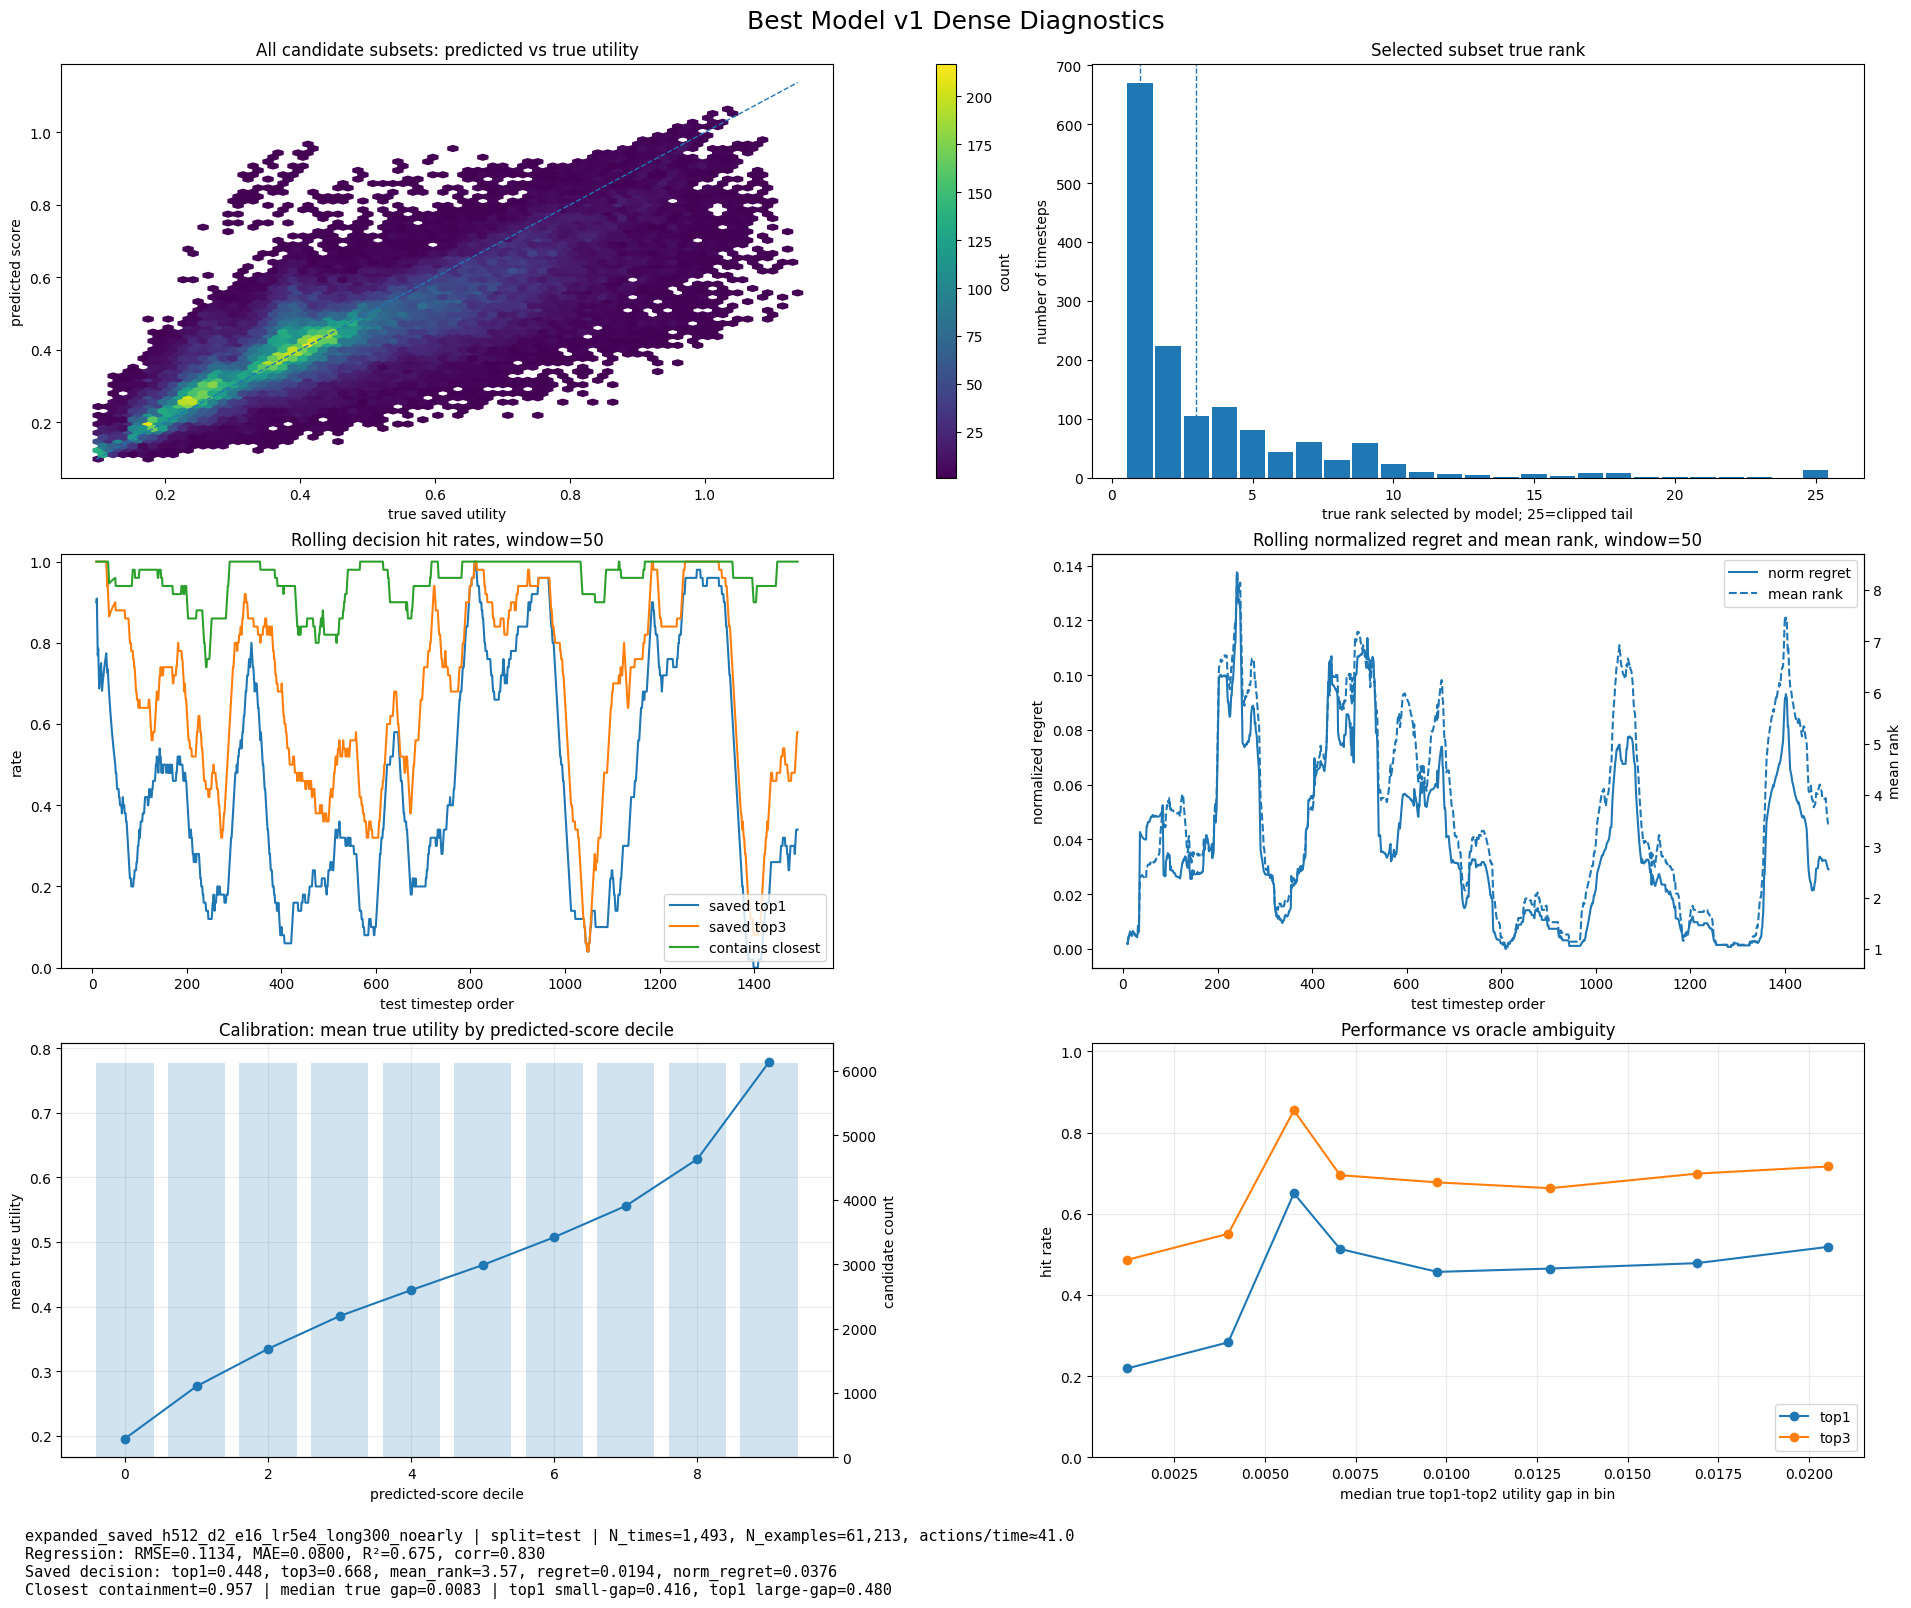

,run_name,split,n_times,n_examples,actions_per_time_mean,rmse,mae,r2,corr,saved_top1,...,mean_rank,avg_regret,avg_norm_regret,contains_closest,median_true_top1_top2_gap,median_model_top1_top2_gap,saved_top1_small_gap,saved_top1_large_gap,norm_regret_small_gap,norm_regret_large_gap
0,expanded_saved_h512_d2_e16_lr5e4_long300_noearly,test,1493,61213,41.0,0.113432,0.079958,0.675133,0.830333,0.448091,...,3.569324,0.019418,0.03758,0.957133,0.008303,0.010989,0.416332,0.479893,0.029084,0.046088


,time_id,top1,top3,rank,regret,norm_regret,contains_closest,selected_value,best_value,worst_value,true_top1_top2_gap,model_top1_top2_gap,selected_score
0,5972,1.0,1.0,1.0,0.0,0.0,1.0,0.390083,0.390083,0.102026,0.005533,0.006686,0.613714
1,5973,1.0,1.0,1.0,0.0,0.0,1.0,0.394812,0.394812,0.102532,0.005616,0.034314,0.612935
2,5974,1.0,1.0,1.0,0.0,0.0,1.0,0.399657,0.399657,0.103043,0.005700,0.048280,0.578835
3,5975,1.0,1.0,1.0,0.0,0.0,1.0,0.405244,0.405244,0.103641,0.005827,0.017638,0.598403
4,5976,1.0,1.0,1.0,0.0,0.0,1.0,0.410995,0.410995,0.104245,0.005958,0.038458,0.647314


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from two_tower_training import build_utility_labels, predict_scores


def dense_model_diagnostics(
    result,
    split_name="test",
    utility_name="saved",
    utility_kwargs=None,
    closest_utility_name="closest_binary",
    max_scatter_points=120_000,
    rolling_window=None,
    seed=0,
):
    utility_kwargs = utility_kwargs or {}

    model = result["model"]
    prepared = result["prepared"]
    config = result["config"]
    device = result.get("device", "cuda" if torch.cuda.is_available() else "cpu")

    indices = prepared["split"][split_name]
    time_id = prepared["example_time_id"][indices]

    y_saved_all = build_utility_labels(
        examples_index=prepared["examples_index"],
        saved_y=prepared["saved_y_examples"],
        meta=prepared["meta"],
        utility_name=utility_name,
        utility_kwargs=utility_kwargs,
    ).astype(np.float32)

    y_closest_all = build_utility_labels(
        examples_index=prepared["examples_index"],
        saved_y=prepared["saved_y_examples"],
        meta=prepared["meta"],
        utility_name=closest_utility_name,
        utility_kwargs={},
    ).astype(np.float32)

    y_true = y_saved_all[indices]
    y_closest = y_closest_all[indices]

    scores = predict_scores(
        model,
        prepared,
        indices,
        config.batch_size * 2,
        device,
    ).astype(np.float32)

    example_df = pd.DataFrame({
        "time_id": time_id,
        "y_true": y_true,
        "y_closest": y_closest,
        "score": scores,
    })

    rows = []
    eps = 1e-10

    for tid, g in example_df.groupby("time_id", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        yc = g["y_closest"].to_numpy(dtype=float)
        sc = g["score"].to_numpy(dtype=float)

        pred_idx = int(np.argmax(sc))
        selected_value = float(yt[pred_idx])
        selected_closest = float(yc[pred_idx] > 0.5)

        true_sorted = np.sort(yt)[::-1]
        best_value = float(true_sorted[0])
        second_best_value = float(true_sorted[1]) if len(true_sorted) > 1 else best_value
        worst_value = float(true_sorted[-1])

        score_sorted = np.sort(sc)[::-1]
        score_gap = float(score_sorted[0] - score_sorted[1]) if len(score_sorted) > 1 else 0.0
        true_gap = float(best_value - second_best_value)

        rank = int(np.sum(yt > selected_value + eps)) + 1
        regret = best_value - selected_value
        denom = best_value - worst_value
        norm_regret = 0.0 if denom <= 1e-12 else regret / denom

        rows.append({
            "time_id": tid,
            "top1": float(rank == 1),
            "top3": float(rank <= 3),
            "rank": float(rank),
            "regret": float(regret),
            "norm_regret": float(norm_regret),
            "contains_closest": selected_closest,
            "selected_value": selected_value,
            "best_value": best_value,
            "worst_value": worst_value,
            "true_top1_top2_gap": true_gap,
            "model_top1_top2_gap": score_gap,
            "selected_score": float(sc[pred_idx]),
        })

    decision_df = pd.DataFrame(rows).sort_values("time_id").reset_index(drop=True)

    # Regression metrics over all candidate subsets.
    err = scores - y_true
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    sse = float(np.sum(err ** 2))
    sst = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = float(1.0 - sse / max(sst, 1e-12))
    corr = float(np.corrcoef(scores, y_true)[0, 1]) if len(scores) > 1 else np.nan

    # Decision metrics.
    metrics = {
        "run_name": config.run_name,
        "split": split_name,
        "n_times": int(decision_df.shape[0]),
        "n_examples": int(example_df.shape[0]),
        "actions_per_time_mean": float(example_df.groupby("time_id").size().mean()),
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "saved_top1": float(decision_df["top1"].mean()),
        "saved_top3": float(decision_df["top3"].mean()),
        "mean_rank": float(decision_df["rank"].mean()),
        "avg_regret": float(decision_df["regret"].mean()),
        "avg_norm_regret": float(decision_df["norm_regret"].mean()),
        "contains_closest": float(decision_df["contains_closest"].mean()),
        "median_true_top1_top2_gap": float(decision_df["true_top1_top2_gap"].median()),
        "median_model_top1_top2_gap": float(decision_df["model_top1_top2_gap"].median()),
    }

    gap_median = decision_df["true_top1_top2_gap"].median()
    small_gap = decision_df["true_top1_top2_gap"] <= gap_median
    large_gap = decision_df["true_top1_top2_gap"] > gap_median

    metrics["saved_top1_small_gap"] = float(decision_df.loc[small_gap, "top1"].mean())
    metrics["saved_top1_large_gap"] = float(decision_df.loc[large_gap, "top1"].mean())
    metrics["norm_regret_small_gap"] = float(decision_df.loc[small_gap, "norm_regret"].mean())
    metrics["norm_regret_large_gap"] = float(decision_df.loc[large_gap, "norm_regret"].mean())

    # Dense 3x2 figure.
    if rolling_window is None:
        rolling_window = max(50, len(decision_df) // 60)

    fig, axes = plt.subplots(3, 2, figsize=(19, 15), constrained_layout=True)
    ax = axes.ravel()

    # ------------------------------------------------------------------
    # 1. Predicted vs true utility
    # ------------------------------------------------------------------
    rng = np.random.default_rng(seed)
    n = len(example_df)
    if n > max_scatter_points:
        sample_idx = rng.choice(n, size=max_scatter_points, replace=False)
        plot_scores = scores[sample_idx]
        plot_true = y_true[sample_idx]
    else:
        plot_scores = scores
        plot_true = y_true

    hb = ax[0].hexbin(plot_true, plot_scores, gridsize=70, mincnt=1)
    fig.colorbar(hb, ax=ax[0], label="count")
    lo = float(min(np.min(plot_true), np.min(plot_scores)))
    hi = float(max(np.max(plot_true), np.max(plot_scores)))
    ax[0].plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
    ax[0].set_title("All candidate subsets: predicted vs true utility")
    ax[0].set_xlabel("true saved utility")
    ax[0].set_ylabel("predicted score")

    # ------------------------------------------------------------------
    # 2. True rank of selected subset
    # ------------------------------------------------------------------
    max_rank_to_show = int(min(25, decision_df["rank"].max()))
    rank_bins = np.arange(1, max_rank_to_show + 2) - 0.5
    clipped_rank = decision_df["rank"].clip(upper=max_rank_to_show)

    ax[1].hist(clipped_rank, bins=rank_bins, rwidth=0.9)
    ax[1].set_title("Selected subset true rank")
    ax[1].set_xlabel(f"true rank selected by model; {max_rank_to_show}=clipped tail")
    ax[1].set_ylabel("number of timesteps")
    ax[1].axvline(1, linestyle="--", linewidth=1)
    ax[1].axvline(3, linestyle="--", linewidth=1)

    # ------------------------------------------------------------------
    # 3. Rolling hit rates
    # ------------------------------------------------------------------
    roll = decision_df[["top1", "top3", "contains_closest"]].rolling(
        rolling_window,
        min_periods=max(10, rolling_window // 5),
    ).mean()

    ax[2].plot(roll.index, roll["top1"], label="saved top1")
    ax[2].plot(roll.index, roll["top3"], label="saved top3")
    ax[2].plot(roll.index, roll["contains_closest"], label="contains closest")
    ax[2].set_title(f"Rolling decision hit rates, window={rolling_window}")
    ax[2].set_xlabel("test timestep order")
    ax[2].set_ylabel("rate")
    ax[2].set_ylim(0, 1.02)
    ax[2].legend(loc="lower right")

    # ------------------------------------------------------------------
    # 4. Rolling regret and rank
    # ------------------------------------------------------------------
    roll2 = decision_df[["norm_regret", "rank"]].rolling(
        rolling_window,
        min_periods=max(10, rolling_window // 5),
    ).mean()

    ax4b = ax[3].twinx()
    l1 = ax[3].plot(roll2.index, roll2["norm_regret"], label="norm regret")
    l2 = ax4b.plot(roll2.index, roll2["rank"], linestyle="--", label="mean rank")
    ax[3].set_title(f"Rolling normalized regret and mean rank, window={rolling_window}")
    ax[3].set_xlabel("test timestep order")
    ax[3].set_ylabel("normalized regret")
    ax4b.set_ylabel("mean rank")

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax[3].legend(lines, labels, loc="upper right")

    # ------------------------------------------------------------------
    # 5. Calibration / monotonicity by predicted-score decile
    # ------------------------------------------------------------------
    cal_df = example_df.copy()
    cal_df["score_decile"] = pd.qcut(
        cal_df["score"],
        q=10,
        labels=False,
        duplicates="drop",
    )

    cal = (
        cal_df.groupby("score_decile", observed=True)
        .agg(
            mean_score=("score", "mean"),
            mean_true=("y_true", "mean"),
            std_true=("y_true", "std"),
            count=("y_true", "size"),
        )
        .reset_index()
    )

    ax[4].plot(cal["score_decile"], cal["mean_true"], marker="o", label="mean true utility")
    ax[4].set_title("Calibration: mean true utility by predicted-score decile")
    ax[4].set_xlabel("predicted-score decile")
    ax[4].set_ylabel("mean true utility")
    ax[4].grid(True, alpha=0.25)

    ax4count = ax[4].twinx()
    ax4count.bar(cal["score_decile"], cal["count"], alpha=0.2, label="count")
    ax4count.set_ylabel("candidate count")

    # ------------------------------------------------------------------
    # 6. Ambiguity: top1 success vs oracle top1-top2 gap
    # ------------------------------------------------------------------
    amb_df = decision_df.copy()
    amb_df["gap_bin"] = pd.qcut(
        amb_df["true_top1_top2_gap"],
        q=8,
        labels=False,
        duplicates="drop",
    )

    gap_stats = (
        amb_df.groupby("gap_bin", observed=True)
        .agg(
            median_gap=("true_top1_top2_gap", "median"),
            top1=("top1", "mean"),
            top3=("top3", "mean"),
            norm_regret=("norm_regret", "mean"),
            count=("top1", "size"),
        )
        .reset_index()
    )

    ax[5].plot(gap_stats["median_gap"], gap_stats["top1"], marker="o", label="top1")
    ax[5].plot(gap_stats["median_gap"], gap_stats["top3"], marker="o", label="top3")
    ax[5].set_title("Performance vs oracle ambiguity")
    ax[5].set_xlabel("median true top1-top2 utility gap in bin")
    ax[5].set_ylabel("hit rate")
    ax[5].set_ylim(0, 1.02)
    ax[5].legend(loc="lower right")
    ax[5].grid(True, alpha=0.25)

    summary_text = (
        f"{metrics['run_name']} | split={metrics['split']} | "
        f"N_times={metrics['n_times']:,}, N_examples={metrics['n_examples']:,}, "
        f"actions/time≈{metrics['actions_per_time_mean']:.1f}\n"
        f"Regression: RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}, "
        f"R²={metrics['r2']:.3f}, corr={metrics['corr']:.3f}\n"
        f"Saved decision: top1={metrics['saved_top1']:.3f}, top3={metrics['saved_top3']:.3f}, "
        f"mean_rank={metrics['mean_rank']:.2f}, regret={metrics['avg_regret']:.4f}, "
        f"norm_regret={metrics['avg_norm_regret']:.4f}\n"
        f"Closest containment={metrics['contains_closest']:.3f} | "
        f"median true gap={metrics['median_true_top1_top2_gap']:.4f} | "
        f"top1 small-gap={metrics['saved_top1_small_gap']:.3f}, "
        f"top1 large-gap={metrics['saved_top1_large_gap']:.3f}"
    )

    fig.suptitle("Best Model v1 Dense Diagnostics", fontsize=18)
    fig.text(
        0.01,
        -0.015,
        summary_text,
        ha="left",
        va="top",
        fontsize=11,
        family="monospace",
    )

    plt.show()

    metrics_df = pd.DataFrame([metrics])

    return metrics_df, decision_df, example_df, fig


metrics_df, decision_df, example_df, fig = dense_model_diagnostics(
    best_modelv1_result,
    split_name="test",
    utility_name="saved",
    rolling_window=None,
    max_scatter_points=120_000,
)

display(metrics_df)
display(decision_df.head())